In [ ]:
import pandas as pd

df = pd.read_csv('copilot.csv')
df.head()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN


In [ ]:
df.shape

(28587, 16)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28587 entries, 0 to 28586
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   subject   24749 non-null  object
 1   body      28587 non-null  object
 2   answer    28580 non-null  object
 3   type      28587 non-null  object
 4   queue     28587 non-null  object
 5   priority  28587 non-null  object
 6   language  28587 non-null  object
 7   version   28587 non-null  int64 
 8   tag_1     28587 non-null  object
 9   tag_2     28574 non-null  object
 10  tag_3     28451 non-null  object
 11  tag_4     25529 non-null  object
 12  tag_5     14545 non-null  object
 13  tag_6     5874 non-null   object
 14  tag_7     2040 non-null   object
 15  tag_8     565 non-null    object
dtypes: int64(1), object(15)
memory usage: 3.5+ MB


In [ ]:
df.columns.to_list()

['subject',
 'body',
 'answer',
 'type',
 'queue',
 'priority',
 'language',
 'version',
 'tag_1',
 'tag_2',
 'tag_3',
 'tag_4',
 'tag_5',
 'tag_6',
 'tag_7',
 'tag_8']

In [ ]:
# finding missing values

df.isnull().sum()

,0
subject,3838
body,0
answer,7
type,0
queue,0
priority,0
language,0
version,0
tag_1,0
tag_2,13


In [ ]:
# check for duplicates

print(df.duplicated().sum())


0


In [ ]:
# Check the count of target columns

print('Queue')
print(df['queue'].value_counts())

print('\nType')
print(df['type'].value_counts())

print('\nPriority')
print(df['priority'].value_counts())

print('\nLanguage')
print(df['language'].value_counts())

Queue
queue
Technical Support                  8362
Product Support                    5252
Customer Service                   4268
IT Support                         3433
Billing and Payments               2788
Returns and Exchanges              1437
Service Outages and Maintenance    1148
Sales and Pre-Sales                 918
Human Resources                     576
General Inquiry                     405
Name: count, dtype: int64

Type
type
Incident    11466
Request      8187
Problem      6012
Change       2922
Name: count, dtype: int64

Priority
priority
medium    11515
high      11178
low        5894
Name: count, dtype: int64

Language
language
en    16338
de    12249
Name: count, dtype: int64


**We require particular labels but the dataset has its own labels, so we going to rename them for better understanding.**

In [ ]:

pd.set_option("display.max_colwidth", 200)

print("\nSample support tickets:")

display(
    df[
        [
            "subject",
            "body",
            "type",
            "queue",
            "priority"
        ]
    ].head(10)
)



Sample support tickets:


,subject,body,type,queue,priority
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte einen gravierenden Sicherheitsvorfall melden, der gegenwärtig mehrere Komponenten unserer Infrastruktur betrifft. Betroffene Geräte umfassen Projektoren, ...",Incident,Technical Support,high
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to report a significant problem with the centralized account management portal, which currently appears to be offline. This outage is blocking access to...",Incident,Technical Support,high
2,Query About Smart Home System Integration Features,"Dear Customer Support Team,\n\nI hope this message reaches you well. I am reaching out to request detailed information about the capabilities of your smart home integration products listed on your...",Request,Returns and Exchanges,medium
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this message finds you well. I am reaching out to request clarification about the billing and payment procedures linked to my account. Recently, I observed so...",Request,Billing and Payments,low
4,Question About Marketing Agency Software Compatibility,"Dear Support Team,\n\nI hope this message reaches you well. I am reaching out to ask about the compatibility of your products with the specific needs of marketing agencies. Our company is consider...",Problem,Sales and Pre-Sales,medium
5,Feature Query,"Dear Customer Support,\n\nI hope this message reaches you in good health. I am eager to learn more about the features of one of your products. Would you be able to share comprehensive details abou...",Request,Technical Support,high
6,System Interruptions,"Dear Customer Support Team,\n\nI am submitting a report regarding multiple system service disruptions that are currently interfering with project operations and client interactions. These interrup...",Incident,Service Outages and Maintenance,high
7,Connectivity Problems with Printer on MacBook Pro,"Dear Support Team,\n\nI am reporting a recurring issue with the Laser Printer when printing from MacBook Pros running macOS 15. Several team members have recently encountered this problem, which a...",Incident,Technical Support,medium
8,Anfrage nach detaillierten Angaben zur Systemarchitektur der Plattform,"Sehr geehrtes Kundensupport-Team,\n\nich hoffe, diese Nachricht trifft Sie wohl. Ich nehme Kontakt auf, um umfassende Informationen zur Architektur der Plattform zu erfragen. Das Verständnis der z...",Request,Technical Support,low
9,Anfrage zur Klärung der Auswirkungen eines Serviceausfalls,"Sehr geehrtes Kundendienstteam,\n\nich hoffe, diese Nachricht erreicht Sie wohlbehalten. Ich schreibe, um eine Klärung bezüglich des kürzlichen Ausfalls Ihres Dienstes zu bitten, der die Plattform...",Request,Service Outages and Maintenance,high


In [ ]:
# Inspect invididual ticket

for i in range(5):

    print("\n" + "=" * 80)

    print("TICKET", i + 1)

    print("SUBJECT:")
    print(df.iloc[i]["subject"])

    print("\nBODY:")
    print(df.iloc[i]["body"])

    print("\nTYPE:")
    print(df.iloc[i]["type"])

    print("\nQUEUE:")
    print(df.iloc[i]["queue"])

    print("\nPRIORITY:")
    print(df.iloc[i]["priority"])



TICKET 1
SUBJECT:
Wesentlicher Sicherheitsvorfall

BODY:
Sehr geehrtes Support-Team,\n\nich möchte einen gravierenden Sicherheitsvorfall melden, der gegenwärtig mehrere Komponenten unserer Infrastruktur betrifft. Betroffene Geräte umfassen Projektoren, Bildschirme und Speicherlösungen auf Cloud-Plattformen. Der Grund für die Annahme ist, dass der Vorfall eine potenzielle Datenverletzung im Zusammenhang mit einer Cyberattacke darstellt, was ein erhebliches Risiko für sensible Informationen und den laufenden Geschäftsbetrieb unserer Organisation bedeutet.\n\nUnsere initialen Untersuchungen haben ungewöhnliche Aktivitäten und Abweichungen bei den Geräten ergeben. Trotz der Umsetzung unserer standardisierten Behebungs- und Eindämmungsmaßnahmen konnte die Bedrohung bislang nicht vollständig eliminiert.

TYPE:
Incident

QUEUE:
Technical Support

PRIORITY:
high

TICKET 2
SUBJECT:
Account Disruption

BODY:
Dear Customer Support Team,\n\nI am writing to report a significant problem with the ce

In [ ]:

# CREATE INITIAL QUEUE → CATEGORY MAPPING

queue_to_category = {

    "billing and payments": "billing",

    "returns and exchanges": "refund",

    "technical support": "bug",

    "service outages and maintenance": "bug",

    "it support": "bug",

    "account and login": "account",

    "sales and pre-sales": "other",

    "customer service": "other",

    "product support": "other",

    "general inquiry": "other",

    "human resources": "other"
}

df["category"] = df["queue"].map(queue_to_category)
print(df['category'].value_counts())

Series([], Name: count, dtype: int64)


In [ ]:
print(df["category"].isnull().sum())

28587


In [ ]:
# Show queues that were NOT found in our mapping
unmapped_queues = df.loc[
    df['category'].isnull(),
    "queue"

].value_counts()

print(unmapped_queues)

queue
Technical Support                  8362
Product Support                    5252
Customer Service                   4268
IT Support                         3433
Billing and Payments               2788
Returns and Exchanges              1437
Service Outages and Maintenance    1148
Sales and Pre-Sales                 918
Human Resources                     576
General Inquiry                     405
Name: count, dtype: int64


In [ ]:
# CATEGORY DISTRIBUTION

print("\nCategory Distribution")
print(df['category'].value_counts(dropna=False))


Category Distribution
category
NaN    28587
Name: count, dtype: int64


In [ ]:
# View Queue + Category

print("\nQueue → Category mapping actually applied:")

display(
    df[
        ["queue", "category"]
    ].drop_duplicates().sort_values("queue")
)


Queue → Category mapping actually applied:


,queue,category
3,Billing and Payments,NaN
15,Customer Service,NaN
37,General Inquiry,NaN
21,Human Resources,NaN
12,IT Support,NaN
10,Product Support,NaN
2,Returns and Exchanges,NaN
4,Sales and Pre-Sales,NaN
6,Service Outages and Maintenance,NaN
0,Technical Support,NaN


In [ ]:
queue_to_category = {
    "Technical Support": "bug",
    "Product Support": "other",
    "Customer Service": "other",
    "IT Support": "bug",
    "Billing and Payments": "billing",
    "Returns and Exchanges": "refund",
    "Service Outages and Maintenance": "bug",
    "Sales and Pre-Sales": "other",
    "Human Resources": "other",
    "General Inquiry": "other"
}

df["category"] = df["queue"].map(queue_to_category)

print("Missing categories:", df["category"].isnull().sum())

print("\nCategory distribution:")
print(df["category"].value_counts())

Missing categories: 0

Category distribution:
category
bug        12943
other      11419
billing     2788
refund      1437
Name: count, dtype: int64


In [ ]:
df[df["category"].isnull()][
    ["subject", "body", "type", "queue", "priority"]
]

,subject,body,type,queue,priority


In [ ]:
df[df["category"].isnull()]["queue"]

,queue


In [ ]:
print("Total rows:", len(df))
print("Missing queue:", df["queue"].isnull().sum())
print("Missing category:", df["category"].isnull().sum())

Total rows: 28587
Missing queue: 0
Missing category: 0


In [ ]:
df[df["category"].isnull()][
    ["subject", "body", "type", "queue", "priority"]]

,subject,body,type,queue,priority


We only have one missing value, so we need to fix it

In [ ]:
df.loc[df["category"].isnull(), "category"] = "billing"

In [ ]:
print("Missing categories:", df["category"].isnull().sum())

Missing categories: 0


In [ ]:
print(df["category"].value_counts())

category
bug        12943
other      11419
billing     2788
refund      1437
Name: count, dtype: int64


In [ ]:
# We need to investigate tickets

# Account labels

account_words = [
    "login",
    "log in",
    "sign in",
    "password",
    "account",
    "locked out"
]

account_mask = df["body"].str.lower().str.contains(
    "|".join(account_words),
    na=False
)

print("Potential account tickets:", account_mask.sum())

display(
    df.loc[
        account_mask,
        ["subject", "body", "queue", "category"]
    ].head(20)
)

Potential account tickets: 1185


,subject,body,queue,category
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to report a significant problem with the centralized account management portal, which currently appears to be offline. This outage is blocking access to...",Technical Support,bug
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this message finds you well. I am reaching out to request clarification about the billing and payment procedures linked to my account. Recently, I observed so...",Billing and Payments,billing
15,Inquiry for In-Depth Details on Financial Institution Offerings,"Dear Customer Support Team,\n\nI hope this message reaches you in good health. I am writing to request detailed information about the spectrum of products provided by your financial institution. A...",Customer Service,other
16,Enhancing Multi-Unit Marketing Processes,"Dear Customer Support Team,\n\nI am reaching out to request comprehensive details on optimizing marketing workflows across multiple departments by utilizing advanced analytics, automation, and cen...",Technical Support,bug
25,Verbindungsstörung,"Sehr geehrtes Support-Team,\n\nich möchte ein Verbindungsproblem melden, das meinen Account im Management Hub betrifft. Trotz mehrmaliger Versuche, auf den Hub zuzugreifen, wird die effiziente Ver...",IT Support,bug
30,Problem with Payment Billing Procedures,"Customer Service, I am reaching out to report an issue with the billing payment process on my account. Recently, there have been inconsistencies in the billed amounts and delays in confirming paym...",Billing and Payments,billing
37,Organizational Revision,"Dear Customer Support Team,\n\nI am reaching out to request an update on the structural details of our organization. The current records reflect information about the marketing agency, which has r...",General Inquiry,other
47,Revise Marketing Firm Framework,"Dear Customer Service Team,\n\nI am reaching out to request modifications to the marketing firm's framework. I wish to incorporate new technologies to broaden our existing offerings, including dat...",Customer Service,other
60,Discrepancies in Recent Billing Statement,"Dear Customer Support,\n\nI am submitting a report concerning errors in the latest billing statement. It seems that the automated billing system may have incorrectly allocated hardware purchases a...",Billing and Payments,billing
67,Problem Report,"Customer Support,\n\nI am facing difficulties with the centralized account administration process. Although the features seem to be functioning normally, there are delays and confusion when handli...",Product Support,other


In [ ]:
# Check Feature Labels

feature_words = [
    "feature request",
    "new feature",
    "add a feature",
    "would like",
    "could you add",
    "please add",
    "feature"
]

feature_mask = df["body"].str.lower().str.contains(
    "|".join(feature_words),
    na=False
)

print("Potential feature-request tickets:", feature_mask.sum())

display(
    df.loc[
        feature_mask,
        ["subject", "body", "queue", "category"]
    ].head(20)
)

Potential feature-request tickets: 2324


,subject,body,queue,category
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this message finds you well. I am reaching out to request clarification about the billing and payment procedures linked to my account. Recently, I observed so...",Billing and Payments,billing
5,Feature Query,"Dear Customer Support,\n\nI hope this message reaches you in good health. I am eager to learn more about the features of one of your products. Would you be able to share comprehensive details abou...",Technical Support,bug
11,Issue with SaaS Platform Functionality,"Sehr geehrtes Support-Team,\n\nich möchte Sie auf einen Ausfall der Funktionen unserer SaaS-Plattform aufmerksam machen, den wir momentan erleben. In den letzten Stunden sind mehrere zentrale Feat...",Product Support,other
12,Immediate Help Needed: Technical Problem with Cloud SaaS Service,"Dear Customer Support Team,\n\nI am submitting a report regarding a technical problem encountered with the Cloud SaaS platform, which is currently disrupting our business activities. I have observ...",IT Support,bug
15,Inquiry for In-Depth Details on Financial Institution Offerings,"Dear Customer Support Team,\n\nI hope this message reaches you in good health. I am writing to request detailed information about the spectrum of products provided by your financial institution. A...",Customer Service,other
16,Enhancing Multi-Unit Marketing Processes,"Dear Customer Support Team,\n\nI am reaching out to request comprehensive details on optimizing marketing workflows across multiple departments by utilizing advanced analytics, automation, and cen...",Technical Support,bug
17,Inquiry for Comprehensive Marketing Service Details,"Dear Customer Support Team,\n\nI hope this message reaches you well. I am writing to request detailed information about your marketing offerings. Our company is currently considering new marketing...",Customer Service,other
37,Organizational Revision,"Dear Customer Support Team,\n\nI am reaching out to request an update on the structural details of our organization. The current records reflect information about the marketing agency, which has r...",General Inquiry,other
47,Revise Marketing Firm Framework,"Dear Customer Service Team,\n\nI am reaching out to request modifications to the marketing firm's framework. I wish to incorporate new technologies to broaden our existing offerings, including dat...",Customer Service,other
52,Integration of Configuration Modifications,"Dear Support Team,\n\nI hope this message reaches you well. I am reaching out to request assistance with several configuration modifications and integrations that are essential for enhancing our w...",Technical Support,bug


**We noticed that a keyword such as "account" does not necessarily mean the ticket's intent is account. The same applies to "feature".**

In [ ]:
# We check samples randomly from account and features

# Acount tickets
display(
    df.loc[
        account_mask,
        ["subject", "body", "queue", "category"]
    ].sample(20, random_state=42)
)


,subject,body,queue,category
6669,Reported Security Vulnerability Due to Data Breach,"A healthcare organization encountered unauthorized access to sensitive data, likely stemming from outdated security measures. Basic firewall updates and password modifications have been applied, y...",Product Support,other
22500,Security concern in medical system,unauthorized login attempts detected,Customer Service,other
28479,Problems with Platform Login,"Users are experiencing temporary login issues with the platform. These may be due to recent updates of the authentication servers. Try clearing your browser cache and cookies, as this may resolve ...",Technical Support,bug
722,Payment Details for Billing,"Dear Customer Support,\n\nI am reaching out to request a detailed statement of billing payments for my recent acquisitions of hardware and software, including peripheral devices and computers. The...",Billing and Payments,billing
23237,NaN,"Customer support, a data breach has been detected in the hospital's systems, posing a threat to medical data security. We have already updated the software, enforced stronger passwords, and traine...",IT Support,bug
10853,Issue with Billing Digital Products,"Dear Support Team, I am writing to report a billing error. Overcharges on several digital products have occurred. The issue seems to have arisen due to systematic errors following the last update....",Billing and Payments,billing
24468,Support for AI Hospital Access Control Issue,"An unauthorized access control check on the hospital IT system has been identified. Potential causes include network vulnerabilities and lost user credentials. Measures such as system backup, pass...",Technical Support,bug
22147,Support Request for Unauthorized Access Attempt in Secure Healthcare Data System,"We have identified an unauthorized access attempt on the secured healthcare data system, which may have occurred due to a software vulnerability. After analyzing the logs and updating passwords, w...",Returns and Exchanges,refund
6848,Optimierung der digitalen Marketing-Workflows,"Sehr geehrter Kundenservice,\n\nich möchte mich erkundigen, ob es möglich ist, Adobe Sign in die ClickUp-Workflows für digitales Marketing zu integrieren. Unser Team nutzt ClickUp für Aufgabenmana...",Technical Support,bug
8092,Urgent: Healthcare Provider Data Access Issue,"Customer support reports a serious problem affecting data access for a healthcare provider. The hospital's system, which runs multiple software applications, is encountering difficulties that may ...",IT Support,bug


In [ ]:
# Feature tickets
display(
    df.loc[
        feature_mask,
        ["subject","body","queue","category"]
    ].sample(20, random_state=42)
)

,subject,body,queue,category
19307,Support for Secure Management of Medical Information with CyberLink PowerDirector 19,I am reaching out to Customer Support seeking assistance in securing medical data using CyberLink PowerDirector 19 in a hospital setting. Could you provide guidance on best practices to ensure the...,IT Support,bug
10819,Support for Smart Tracker Investment Analytics,Could you provide more detailed information on the data analysis features within Smart-Tracker for optimizing investments? I would like to understand the tools and insights offered to make informe...,Product Support,other
20000,Inquiry on HubSpot Integration Features,Looking to understand the integration capabilities between HubSpot CRM and project management SaaS solutions. Could you provide more details on how these systems work together seamlessly? Specific...,Product Support,other
21534,Guidance on Securing Medical Data in Docker Django Environment,"Dear Customer Support, I am reaching out to seek guidance on securing medical data for our hospital's system. Currently, we are using Docker Django 3.2, and I would like to know best practices for...",IT Support,bug
21830,Guidance on Investment Strategy Tools,I am in need of assistance with the analytics tools available to optimize my investment strategies. Could you provide details on the types of tools that are offered and how they can be utilized to...,IT Support,bug
5600,NaN,"Customer Support, I am reaching out to inquire about integrating Firebase with a scalable SaaS project management platform. Could you provide comprehensive integration instructions using the Fireb...",Customer Service,other
11886,Enquiry on Customization Options for SaaS Project Management Tools,Could you furnish details on the customization options for SaaS project management features? I am keen to learn about a platform that can be tailored to meet our specific needs. Please provide inf...,Human Resources,other
12488,NaN,"Dear Customer Support Team, I am reaching out to request the integration of user-friendly features in our project management SaaS application to improve its usability across all devices and applic...",General Inquiry,other
12515,PrestaShop Integration Features Request,"I am interested in learning about the integration features between PrestaShop and Shopware within a SaaS solution. Could you provide information on the available integrations, data synchronization...",Product Support,other
11359,Concern About Medical Data Access,"An unexpected access request for medical data has been logged in the hospital system. This could have occurred due to outdated security protocols. After reviewing recent activity logs, it was conf...",Technical Support,bug


Few ticket were incorrectly labeled

**"Problem with Login Sessions → potentially account, although it could also be a technical bug"**

We need to create a pattern for better labeling.

In [ ]:
account_patterns = [
    "forgot my password",
    "reset my password",
    "password reset",
    "cannot log in",
    "can't log in",
    "cannot login",
    "can't login",
    "unable to login",
    "unable to log in",
    "cannot sign in",
    "can't sign in",
    "unable to sign in",
    "account is locked",
    "locked out of my account"
]

In [ ]:
feature_patterns = [
    "can you add",
    "could you add",
    "please add",
    "would like to add",
    "would like the ability",
    "request a feature",
    "feature request",
    "new feature",
    "it would be useful",
    "it would be helpful if",
    "would be great if"
]

In [ ]:
from textwrap import fill
# We create a new columns
# We will use regex to search pattern in text

import re

# combine body and subject

df["text"] = (df["subject"].fillna("") + " " + df["body"].fillna("")).str.lower()

In [ ]:
# find account candidate

account_regex = re.compile("|".join(map(re.escape, account_patterns)), flags=re.IGNORECASE)
account_mask = df["text"].str.contains(account_regex, na=False)
print("Potential account tickets:", account_mask.sum())

Potential account tickets: 70


In [ ]:
# find Feature request candidate

feature_regex = re.compile("|".join(map(re.escape, feature_patterns)), flags=re.IGNORECASE)
feature_mask = df["text"].str.contains(feature_regex, na=False)
print("Potential feature tickets:", feature_mask.sum())

Potential feature tickets: 148


In [ ]:
display(
    df.loc[
        account_mask,
        ["subject", "body", "queue", "category"]
    ].sample(30, random_state=42)
)

,subject,body,queue,category
4933,Detected Unauthorized Access to Hospital Systems,"An incident involving unauthorized access to the hospital's systems has been identified, jeopardizing the security of medical data. It appears a potential phishing attack may have compromised empl...",Product Support,other
589,Immediate Attention Needed: Outlook Email Access Problem,"Dear Customer Support Team,\n\nI am writing to report a serious problem that is preventing users from accessing Outlook email and calendar features. Following a recent system update, there appears...",Technical Support,bug
17384,Report on Frequent Login Issues,"Facing occasional login difficulties, which might be related to server overload during peak activity hours. Even after enhancing server capabilities and refining the login procedure, these problem...",Technical Support,bug
1824,Security Incident Notification,"There is a potential security incident involving the compromise of sensitive medical information due to outdated systems and insufficient staff training. Despite efforts such as software updates, ...",IT Support,bug
20381,Concerning Data Security Incident,"There is a potential data breach in the healthcare system, possibly due to an alleged misconfiguration in security protocols, which has led to unauthorized access. Initial security measures such a...",Technical Support,bug
4090,Support for Incident Reporting,"Detected unauthorized access to the hospital's system. It appears a phishing attack may have exploited insecure credentials. A password reset has been carried out, and monitoring has been increase...",Product Support,other
2423,Report on Data Breach Incident,"Customer Support, I am composing a report regarding a serious incident involving a data breach at a healthcare provider. A suspected phishing attack occurred, leading to the exposure of sensitive ...",Technical Support,bug
7757,NaN,"Customer support team reports a serious issue affecting a healthcare provider's data access. The hospital's system, which runs multiple software applications, is encountering problems that may ste...",IT Support,bug
13487,NaN,"An unauthorized access attempt has been detected in the medical data systems, leading to potential data security concerns. Password resets have been enforced, and access logs have been reviewed fo...",Technical Support,bug
3196,Concern Regarding Breach in Medical Data Security of Hospital Systems,"There has been a reported breach affecting the security of medical data within our hospital systems. Potential causes may include network vulnerabilities, unauthorized access, attempted system sca...",Technical Support,bug


In [ ]:
display(
    df.loc[
        feature_mask,
        ["subject", "body", "queue", "category"]
    ].sample(30, random_state=42)
)

,subject,body,queue,category
24514,Assistance with VLC Media Player,Please contact us to find out how to integrate VLC Media Player into your project management software. Would appreciate more details on the integration process and requirements. It would be great ...,Customer Service,other
11652,Concern Over Medical Data Security Breach,"Customer Support, please address a significant issue with the hospital's systems. An unexpected breach has compromised the security of medical data. Despite recent updates to the software and tigh...",Technical Support,bug
27295,NaN,"Dear Customer Support, please address the urgent matter immediately as a critical issue has been identified. A data breach has been detected, potentially compromising medical records within our ho...",Product Support,other
3683,Request for Updating Investment Analytics Data,"Dear customer support, I am writing to request an update on the integration of investment analytics data into our dashboard visuals, particularly in PowerPoint, Firebase, and Asana. Our current sy...",Billing and Payments,billing
20782,Urgent: Critical Feature Crash in Project Management Software,"Reporting critical issue with project management tool. During load testing, a key feature crashed unexpectedly, even after increasing server capacity. Believe the issue might be due to insufficien...",Technical Support,bug
2226,Seeking Guidance for Node.js Integration,"Dear Customer Support, I am reaching out to request assistance with integrating Node.js 14.17 into our project. We are currently using Node.js 12.22 and wish to upgrade to the latest version to le...",Technical Support,bug
16330,Updates on Cassandra 4.0 for Investment Data Analytics,I am eager to learn about the enhancements in Cassandra 4.0 for investment data analytics. Could you provide details on how these improvements can enhance data processing and analysis for better i...,Sales and Pre-Sales,other
8228,Installation Instructions for PyTorch on Ubuntu,"Customer Support, I am requesting comprehensive instructions for installing and configuring PyTorch on Ubuntu 22.04 LTS. Our team aims to utilize PyTorch's capabilities for machine learning projec...",Product Support,other
16687,NaN,"Customer Support, please address a critical issue in the application as described in the report. The application has been crashing when users try to save project configurations, which may be due t...",Technical Support,bug
1838,Urgent: Request for Immediate Update of Data Analytics Software,"Dear Customer Support, I am submitting a request to update our existing data analytics tools and their software integrations. The current system is outdated, which is negatively impacting the accu...",Returns and Exchanges,refund


In [ ]:
df["initial_category"] = df["queue"].map(queue_to_category)
df["category"] = df["initial_category"]

###**EDA (Exploratory Data Analysis).**

In [ ]:
print(df["category"].value_counts())

category
bug        12943
other      11419
billing     2788
refund      1437
Name: count, dtype: int64


In [ ]:
print(
    df["category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

category
bug        45.28
other      39.94
billing     9.75
refund      5.03
Name: proportion, dtype: float64


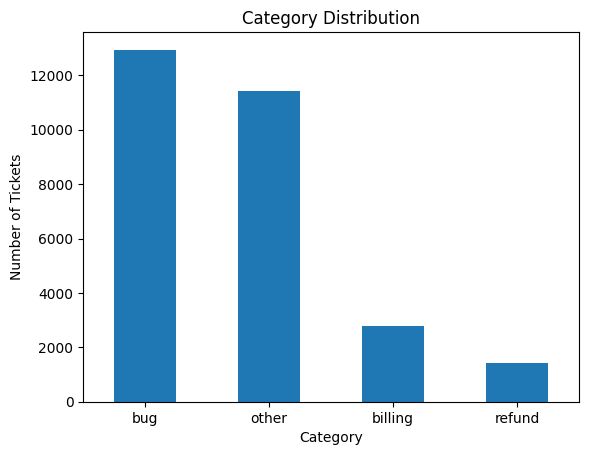

In [ ]:
# Visualize the category columns

import matplotlib.pyplot as plt

df["category"].value_counts().plot(kind="bar")

plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=0)

plt.show()

priority
medium    11515
high      11178
low        5894
Name: count, dtype: int64


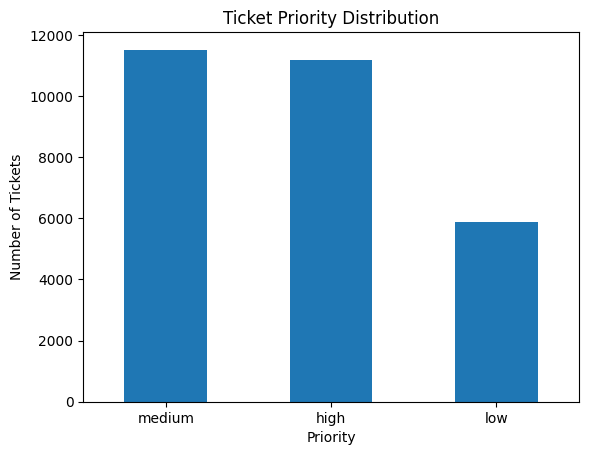

In [ ]:
# check priority distribution
print(df["priority"].value_counts())
df["priority"].value_counts().plot(kind="bar")

plt.title("Ticket Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=0)
plt.show()

In [ ]:
print(df["language"].value_counts(dropna=False))



language
en    16338
de    12249
Name: count, dtype: int64


###**Prepare the ML dataset**

In [ ]:
df_en = df[df["language"]=="en"].copy()

print(f"Original count :{len(df)}")
print(f"English count :{len(df_en)}")

Original count :28587
English count :16338


In [ ]:
# check the categories again
print(df_en["category"].value_counts())

print("\nPercentages of Category Distribution:")
print(
    df_en["category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

category
bug        7343
other      6580
billing    1595
refund      820
Name: count, dtype: int64

Percentages of Category Distribution:
category
bug        44.94
other      40.27
billing     9.76
refund      5.02
Name: proportion, dtype: float64


In [ ]:
# remove the ticket with missing text

df_en["text"] = (
    df_en["subject"].fillna("") + " " +
    df_en["body"].fillna("")
).str.strip()

print("Empty text:", (df_en["text"] == "").sum())

Empty text: 0


###**Create X and y**

In [ ]:
X = df_en["text"]
y = df_en["category"]

print(f"X shape : {X.shape}") # X = What the customer said
print(f"y shape : {y.shape}") # y = What category it belongs to

X shape : (16338,)
y shape : (16338,)


###**Train / Test Split**

We'll keep:

80% training
20% testing

In [ ]:
from numpy import random
from sklearn.model_selection import train_test_split

X_train,X_test, y_train, y_test = train_test_split(X , y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape : {X_train.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"y_test shape : {y_test.shape}")

X_train shape : (13070,)
y_train shape : (13070,)
X_test shape : (3268,)
y_test shape : (3268,)


###**TF-IDF**
**Converting text into numbers**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features = 20000,
    stop_words = "english",
    ngram_range = (1,2),
    lowercase = True
)

Xtrain_tfidf = vectorizer.fit_transform(X_train)
Xtest_tfidf = vectorizer.transform(X_test)

print(f"Xtrain_tfidf shape : {Xtrain_tfidf.shape}")
print(f"Xtest_tfidf shape : {Xtest_tfidf.shape}")

Xtrain_tfidf shape : (13070, 20000)
Xtest_tfidf shape : (3268, 20000)


In [ ]:
print(vectorizer)

TfidfVectorizer(max_features=20000, ngram_range=(1, 2), stop_words='english')


###**Train our first classifier**

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight = "balanced" # tells model to pay more attention to smaller classes.
)

model.fit(Xtrain_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

###**Evalute**

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, f1_score

y_pred = model.predict(Xtest_tfidf)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")
classification_rep = classification_report(y_test, y_pred)

print("Classification Report:")
print(classification_rep)

print("Accuracy:", round(accuracy,4))
print("F1 Score:", f1)


Classification Report:
              precision    recall  f1-score   support

     billing       0.78      0.81      0.80       319
         bug       0.74      0.71      0.72      1469
       other       0.67      0.66      0.67      1316
      refund       0.45      0.65      0.53       164

    accuracy                           0.70      3268
   macro avg       0.66      0.71      0.68      3268
weighted avg       0.70      0.70      0.70      3268

Accuracy: 0.6965
F1 Score: 0.6793546477604879


**Analysis :**

1. Accurracy is almost 70 %, it performed better but not great.
2. The issue is in "Refund", where recall is 65% and precision is 45%.
This is baseline model, so we will check where we went wrong with confusion matrix.

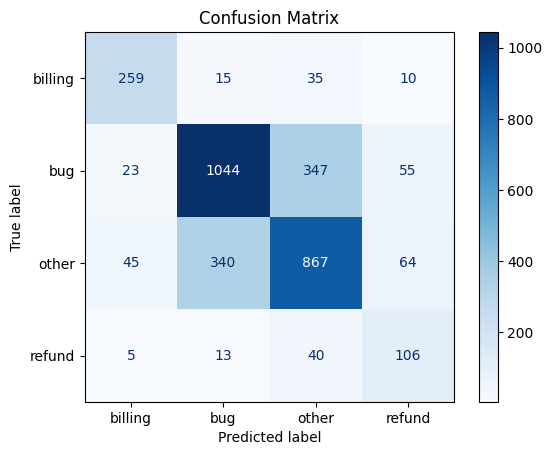

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
results = df_en.loc[X_test.index, [
    "subject",
    "body",
    "category"
]].copy()

results["predicted"] = y_pred

errors = results[
    results["category"] != results["predicted"]
]

print("Total test tickets:", len(results))
print("Incorrect predictions:", len(errors))

Total test tickets: 3268
Incorrect predictions: 992


In [ ]:
display(
    errors[
        ["subject", "body", "category", "predicted"]
    ].sample(20, random_state=42)
)

,subject,body,category,predicted
13473,Problem with Audio Quality During Virtual Meetings,"Dear Customer Support, I am encountering inconsistent audio quality during virtual meetings, which seems to be caused by software conflicts or outdated drivers for my headset. Despite updating the...",other,bug
5130,Teams Express Troubleshooting,Can you supply comprehensive integration instructions for Microsoft Teams Express.js within a scalable SaaS project management system?,bug,refund
12914,Hospital Security Breach Alert,"A security breach has been identified in the hospital's system, posing a risk to medical data due to outdated software and weak access controls.",other,bug
22907,Enhancing Security for Medical Data in Docker Django,"Customer Support, <br>I am seeking guidance on securing medical data for our hospital's system. We are currently using Docker Django 3.2 and would like to know best practices to ensure the confide...",bug,billing
27865,Request for Information on Investment Analytics Tools for QuickBooks Online,"Dear Customer Support, I am reaching out to inquire about the investment analytics tools that are compatible with QuickBooks Online. Could you provide information on the available options and thei...",refund,other
1471,Assistance Needed with Support System,"The firm is facing delays in data processing due to a surge in data volume, which is impacting investment optimization. Multiple system restart attempts have been unsuccessful. The problem continu...",other,bug
23718,Notify About Delay in Loading Data,"Dear Support Team, customers have been experiencing intermittent delays in loading project reports. This could be due to high server traffic. We have already cleared the cache and optimized querie...",other,refund
13869,Problem with Marketing Campaign Launch Delays,There are delays in launching our campaigns due to integration issues with the software tools and platforms.,other,bug
8345,Issue Detected: Underperformance of Digital Campaigns,"The digital campaigns did not meet expectations, potentially due to targeting inaccuracies or platform-related problems. Despite optimizing ads and modifying audience segments, there was no improv...",refund,other
5017,Seeking Assistance for SaaS Platform Integration,"Dear Support Team, I am contacting you to inquire about integrating ClickUp and ActiveCampaign within a scalable SaaS platform. Could you please provide comprehensive details on the process, inclu...",refund,other


Analysis:

There has been bigger issue in "bug" vs "other" and "bug" vs "refund" vs "other".
The labels are imperfect, where we labeled entire "refund and exchange" to "refund", but some tickets were not asking for refunds.

###**Linear SVM**

Linear SVM is often very strong for text classification and is a natural next baseline.

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report

svm_model = LinearSVC(
    class_weight="balanced",
    C=1.0
)

svm_model.fit(Xtrain_tfidf, y_train)

y_pred_svm = svm_model.predict(Xtest_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Macro F1:", f1_score(y_test, y_pred_svm, average="macro"))
print("Weighted F1:", f1_score(y_test, y_pred_svm, average="weighted"))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.758873929008568
Macro F1: 0.7502044777780071
Weighted F1: 0.7585627108770424

Classification Report:
              precision    recall  f1-score   support

     billing       0.86      0.84      0.85       319
         bug       0.77      0.78      0.78      1469
       other       0.73      0.73      0.73      1316
      refund       0.69      0.60      0.64       164

    accuracy                           0.76      3268
   macro avg       0.76      0.74      0.75      3268
weighted avg       0.76      0.76      0.76      3268



In [ ]:
print(svm_model)

LinearSVC(class_weight='balanced')


**Analysis:**

1. SVM performed better.
2. The Accuracy is 75%, the F1 score is 85%, 78%, 73% and refund is 64% which is weakest but better than previous classifier.
3. We will keep Linear SVM as our current best classifier.

**Our next goal should be to build the next component:**

**Step 1 - Urgency Prediction**

Urgency prediction means predicting how quickly a support ticket needs attention.

In [ ]:
import joblib
"""joblib is a super handy Python library for saving and loading models or
large objects efficiently. """

joblib.dump(vectorizer, "tfidf_vectorizer.pkl")
joblib.dump(svm_model, "ticket_classifier_svm.pkl")

print("Models saved successfully!")

Models saved successfully!


In [ ]:
# Our values are stored.
# Let's build urgency model.

print(df_en["priority"].value_counts())

priority
medium    6618
high      6346
low       3374
Name: count, dtype: int64


In [ ]:
# Also, check for missing value in priority.
print("Missing priority:", df_en["priority"].isnull().sum())

Missing priority: 0


In [ ]:
# The priority data is clean and no missing data.

"""
We are going to treat:
high - high urgency
medium - medium urgency
low - low urgency
"""


'\nWe are going to treat:\nhigh - high urgency\nmedium - medium urgency\nlow - low urgency\n'

###**Step 1A : Prepare the urgency data.**

In [ ]:
# we would use the same ticket text used for category prediction.

# First create X and y

X_urgency = df_en["text"]       # the ticket text
y_urgency = df_en["priority"]   # what we want the model to predict.



"I cannot access my account and the entire system is down"
--> "Urgency Model"
--> "High"


###**Step 1B : Split the data**

In [ ]:
from sklearn.model_selection import train_test_split

X_train_urgency, X_test_urgency, y_train_urgency, y_test_urgency = train_test_split(
    X_urgency,y_urgency, test_size=0.2, random_state=42, stratify=y_urgency
)

print(f"Training ticket:{len(X_train_urgency)}")
print(f"Testing ticket:{len(X_test_urgency)}")

Training ticket:13070
Testing ticket:3268


###**Step 1C : Create TF-IDF  for urgency**

**We will create a separate TF-IDG vectorizer as they different ML task, to keep to make them easier to understand and maintain**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

urgency_vectorizer = TfidfVectorizer(
    lowercase = True,
    max_features = 20000,
    stop_words= 'english',
    ngram_range = (1,2)

)

X_train_urgency_tfidf = urgency_vectorizer.fit_transform(X_train_urgency)
X_test_urgency_tfidf = urgency_vectorizer.transform(X_test_urgency)

print(f"X_train_urgency_tfidf shape : {X_train_urgency_tfidf.shape}")
print(f"X_test_urgency_tfidf shape : {X_test_urgency_tfidf.shape}")

X_train_urgency_tfidf shape : (13070, 20000)
X_test_urgency_tfidf shape : (3268, 20000)


###**Step 1D : Train the model**

In [ ]:
from sklearn.linear_model import LogisticRegression

model_urg = LogisticRegression(
    max_iter=1000,
    class_weight = "balanced" # tells model to pay more attention to smaller classes.
)

model_urg.fit(X_train_urgency_tfidf, y_train_urgency)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, f1_score

y_pred_urg = model_urg.predict(X_test_urgency_tfidf)

accuracy_urg = accuracy_score(y_test_urgency , y_pred_urg)
f1_urg = f1_score(y_test_urgency, y_pred_urg, average="macro")
classification_rep_urg = classification_report(y_test_urgency, y_pred_urg)

print("Classification Report:")
print(classification_rep_urg)

print("Accuracy:", round(accuracy_urg,4))
print("F1 Score:", f1_urg)

Classification Report:
              precision    recall  f1-score   support

        high       0.68      0.65      0.66      1269
         low       0.52      0.62      0.57       675
      medium       0.63      0.59      0.61      1324

    accuracy                           0.62      3268
   macro avg       0.61      0.62      0.61      3268
weighted avg       0.63      0.62      0.62      3268

Accuracy: 0.6206
F1 Score: 0.6133236165232853


**Analysis:**
1. The model is showing good result 62% is good result for current model.
2. The model is confusion between high/low and medium, which seems okay, as the text wont be showing urgency signals.

###**Step 1E : Create confusion matrix.**

[[419 163  93]
 [238 780 306]
 [147 293 829]]


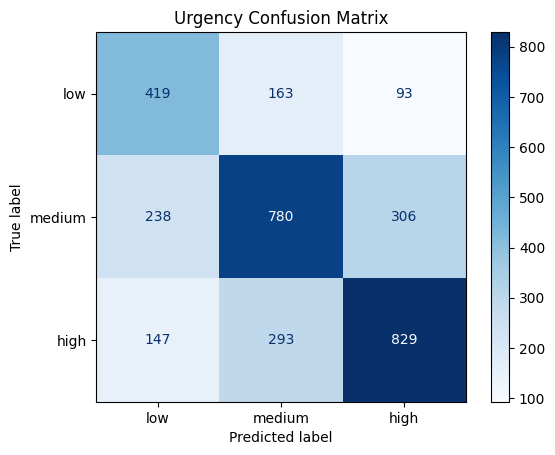

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_urg = confusion_matrix(y_test_urgency, y_pred_urg, labels =['low','medium','high'])

print(cm_urg)

disp_urg = ConfusionMatrixDisplay(
    confusion_matrix = cm_urg,
    display_labels = ['low','medium','high']
)
disp_urg.plot(cmap=plt.cm.Blues)
plt.title("Urgency Confusion Matrix")
plt.show()

In [ ]:
# Inspect actual wrong predictions

results_urgency = X_test_urgency.copy().to_frame()

results_urgency["actual_urgency"] = y_test_urgency.values
results_urgency["predicted_urgency"] = y_pred_urg

wrong_urgency = results_urgency[
    results_urgency["actual_urgency"] !=
    results_urgency["predicted_urgency"]
]

print("Total test tickets:", len(results_urgency))
print("Incorrect predictions:", len(wrong_urgency))

wrong_urgency.head(20)

Total test tickets: 3268
Incorrect predictions: 1240


,text,actual_urgency,predicted_urgency
533,"Billing Concerns for Multiple Subscriptions Dear Customer Support,\n\nI am reaching out to highlight an issue with billing related to several of my product subscriptions. Recently, I observed that...",low,high
12163,Recent Decline in Engagement Metrics Noted Online We have observed a decrease in engagement metrics. This could be due to recent algorithm updates. We have modified our target audience and ad crea...,medium,high
27938,"Support Needed for ClickUp IFTTT Integration I'm encountering difficulties with the integration between ClickUp and IFTTT. My tasks are failing to sync with connected devices, and I suspect it mig...",medium,low
9886,"Data Synchronization Issue Customer Support, reporting an issue with data synchronization across various platforms. The company has encountered failures in syncing data between Airtable, Notion, a...",medium,high
3734,"Support Inquiry Regarding Marketing Automation Dear Customer Support, I am reaching out to request detailed instructions on integrating SendGrid's marketing automation tools to enhance our brand g...",low,medium
5517,"Inquiry About Pricing and Scalability for Project Management SaaS Dear Customer Support, I am reaching out to inquire about the pricing options and scalability features of your project management ...",high,medium
8555,"Incident Notification: Possible Security Breach Detected Yesterday Customer Support,<br><br>I am reaching out to report a significant incident at the hospital. It appears that our systems may have...",high,medium
13731,Support Needed for Login Issues Login difficulties are happening occasionally following the latest software update.,medium,low
24901,Concern Regarding Project Dashboard Load Times Customers encounter occasional delays in dashboard loading,medium,low
3309,"Security Concern Regarding Medical Records Customer Support, I am reaching out to highlight a significant problem faced by our healthcare facility. We are experiencing difficulties accessing data,...",medium,low


**This tells us something important: medium urgency is difficult to distinguish from both high and low. That's quite plausible because urgency is more subjective than ticket category.**

**Let's try Logistic Regression with Balanced Weights**

In [ ]:
from sklearn.linear_model import LogisticRegression

urgency_model_balanced = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

urgency_model_balanced.fit(X_train_urgency_tfidf,y_train_urgency)

y_pred_urgency_balanced = urgency_model_balanced.predict(X_test_urgency_tfidf)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

print(
    "Accuracy:",
    accuracy_score(y_test_urgency, y_pred_urgency_balanced)
)

print(
    "Macro F1:",
    f1_score(
        y_test_urgency,
        y_pred_urgency_balanced,
        average="macro"
    )
)

print(classification_report(
    y_test_urgency,
    y_pred_urgency_balanced
))

Accuracy: 0.620563035495716
Macro F1: 0.6133236165232853
              precision    recall  f1-score   support

        high       0.68      0.65      0.66      1269
         low       0.52      0.62      0.57       675
      medium       0.63      0.59      0.61      1324

    accuracy                           0.62      3268
   macro avg       0.61      0.62      0.61      3268
weighted avg       0.63      0.62      0.62      3268



**Analysis -**
1. It didn't improve the model.
2. We will try with Linear SVM.

In [ ]:
# Linear SVM

from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report

urgency_svm = LinearSVC()

urgency_svm.fit(
    X_train_urgency_tfidf,
    y_train_urgency
)

y_pred_urgency_svm = urgency_svm.predict(
    X_test_urgency_tfidf
)

print(
    "Accuracy:",
    accuracy_score(y_test_urgency, y_pred_urgency_svm)
)

print(
    "Macro F1:",
    f1_score(
        y_test_urgency,
        y_pred_urgency_svm,
        average="macro"
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test_urgency,
        y_pred_urgency_svm
    )
)

Accuracy: 0.6863525091799265
Macro F1: 0.6717063939550941

Classification Report:
              precision    recall  f1-score   support

        high       0.70      0.74      0.72      1269
         low       0.67      0.55      0.60       675
      medium       0.68      0.71      0.69      1324

    accuracy                           0.69      3268
   macro avg       0.68      0.66      0.67      3268
weighted avg       0.69      0.69      0.68      3268



**LinearSVC is clearly the better urgency model.**

Your class-level results also look healthier: F1

High            0.72  
Medium          0.69  
Low             0.60

low is still the hardest class, but overall this is a much better model.

###**Step 2 - Combine category + Urgency model**



In [ ]:
def predict_ticket(ticket_text):
    # Category prediction
    category_tfidf = vectorizer.transform([ticket_text])
    predicted_category = svm_model.predict(category_tfidf)[0]

    # Urgency prediction
    urgency_tfidf = urgency_vectorizer.transform([ticket_text])
    predicted_urgency = urgency_svm.predict(urgency_tfidf)[0]

    return {
        "category": predicted_category,
        "urgency": predicted_urgency
    }

In [ ]:
new_ticket = """
Our application is completely down and customers
are unable to log in. This is affecting many users
and needs immediate attention.
"""

result = predict_ticket(new_ticket)

print("Category:", result["category"])
print("Urgency:", result["urgency"])

Category: bug
Urgency: high


In [ ]:
# Lets try few more examples
tickets = [
    "I was charged twice for my monthly subscription.",
    "I would like to know your pricing plans for enterprise customers.",
    "The website is down and no customers can log in.",
    "I want a refund for my latest purchase."
]

for ticket in tickets:
    result = predict_ticket(ticket)

    print("\nTicket:", ticket)
    print("Category:", result["category"])
    print("Urgency:", result["urgency"])


Ticket: I was charged twice for my monthly subscription.
Category: billing
Urgency: high

Ticket: I would like to know your pricing plans for enterprise customers.
Category: billing
Urgency: high

Ticket: The website is down and no customers can log in.
Category: bug
Urgency: high

Ticket: I want a refund for my latest purchase.
Category: bug
Urgency: high


**Analysis:**

1. Two prediction are clearly questionable: Pricing plans and refund.
2. It looks like all 4 examples are labeled high.

In [ ]:
# Validate with new examples

test_tickets = [
    {
        "text": "I was charged twice for my monthly subscription.",
        "expected_category": "billing",
        "expected_urgency": "medium"
    },
    {
        "text": "I would like to know your pricing plans for enterprise customers.",
        "expected_category": "other",
        "expected_urgency": "low"
    },
    {
        "text": "The website is down and no customers can log in.",
        "expected_category": "bug",
        "expected_urgency": "high"
    },
    {
        "text": "I want a refund for my latest purchase.",
        "expected_category": "refund",
        "expected_urgency": "medium"
    },
    {
        "text": "My account is occasionally slow when loading the dashboard.",
        "expected_category": "bug",
        "expected_urgency": "medium"
    },
    {
        "text": "Can you explain how your subscription works?",
        "expected_category": "other",
        "expected_urgency": "low"
    }
]

In [ ]:
for item in test_tickets:
    result = predict_ticket(item["text"])

    print("\nTicket:", item["text"])

    print(
        "Category:",
        result["category"],
        "| Expected:",
        item["expected_category"]
    )

    print(
        "Urgency:",
        result["urgency"],
        "| Expected:",
        item["expected_urgency"]
    )


Ticket: I was charged twice for my monthly subscription.
Category: billing | Expected: billing
Urgency: high | Expected: medium

Ticket: I would like to know your pricing plans for enterprise customers.
Category: billing | Expected: other
Urgency: high | Expected: low

Ticket: The website is down and no customers can log in.
Category: bug | Expected: bug
Urgency: high | Expected: high

Ticket: I want a refund for my latest purchase.
Category: bug | Expected: refund
Urgency: high | Expected: medium

Ticket: My account is occasionally slow when loading the dashboard.
Category: bug | Expected: bug
Urgency: medium | Expected: medium

Ticket: Can you explain how your subscription works?
Category: billing | Expected: other
Urgency: medium | Expected: low


**Analysis :**

1. The category model is overusing billing, and the urgency model is overusing high on short natural-language tickets.
2. This doesn't mean the training-test accuracy is at fault, we need to inspect error in training data.

In [ ]:
# category inspection

print(df[df["category"] == "refund"]["text"].head(20).to_string(index=False))
print("\n")
print(df[df["category"] == "other"]["text"].head(20).to_string(index=False))

query about smart home system integration features dear customer support team,\n\ni hope this message reaches you well. i am reaching out to request detailed information about the capabilities of y...
anfrage zu sicherheitsvorkehrungen sehr geehrter kundendienst,\n\nich bitte um umfassende details zu den sicherheitsmaßnahmen bei emr/pacs-integrationen mit iot-medizinprodukten. besonders wichtig ...
query regarding customized rule-driven esg investment approaches dear support team,\n\ni hope this message reaches you well. i am reaching out to request comprehensive details about customized rule...
anfrage zur rückerstattung sehr geehrtes support-team,\n\nich hoffe, diese nachricht erreicht sie wohl. ich schreibe, um mich über den ablauf der rückgabe eines produkts zu informieren, das ich kür...
instructions for returning products dear customer support team,\n\ni trust this message reaches you well. i am reaching out to request comprehensive instructions regarding the procedure for return

In [ ]:
# urgency inspection

print(df[df["priority"] == "low"]["text"].head(20).to_string(index=False))
print("\n")
print(df[df["priority"] == "medium"]["text"].head(20).to_string(index=False))

inquiry regarding invoice details dear customer support team,\n\ni hope this message finds you well. i am reaching out to request clarification about the billing and payment procedures linked to my...
anfrage nach detaillierten angaben zur systemarchitektur der plattform sehr geehrtes kundensupport-team,\n\nich hoffe, diese nachricht trifft sie wohl. ich nehme kontakt auf, um umfassende informat...
audio hardware detected dear customer support team,\n\ni am reaching out to request help with a problem i am facing on my pc. recently, the audio hardware is no longer being recognized by the syste...
anfrage zu sicherheitsvorkehrungen sehr geehrter kundendienst,\n\nich bitte um umfassende details zu den sicherheitsmaßnahmen bei emr/pacs-integrationen mit iot-medizinprodukten. besonders wichtig ...
request for ci/cd pipeline documentation dear customer support team,\n\ni hope this message finds you well. i am reaching out to request detailed documentation related to the ci/cd pipeline employ

In [ ]:
test_refunds = [
    "refund",
    "I want a refund",
    "I want a refund for my purchase",
    "Please refund my latest order",
    "I would like to return my product",
    "I want to exchange my product",
    "Request for product return and refund",
    "I was charged and would like my money back"
]

for ticket in test_refunds:
    category_tfidf = vectorizer.transform([ticket])
    prediction = svm_model.predict(category_tfidf)[0]

    print(f"{ticket:<45} → {prediction}")

refund                                        → bug
I want a refund                               → other
I want a refund for my purchase               → other
Please refund my latest order                 → bug
I would like to return my product             → refund
I want to exchange my product                 → refund
Request for product return and refund         → refund
I was charged and would like my money back    → billing


**Analysis :**

1. The pattern is very clear: your model has learned the refund category primarily as returns/exchanges, rather than the word refund itself.
2. So technically the model isn't broken. Our label name refund is a little misleading.
3. Don't retrain the entire model yet. Rename that category concept in your project from refund to something more representative, such as:
returns_refunds

In [ ]:
# let's inspect what words the SVM actually learned for each category

import numpy as np

feature_names = vectorizer.get_feature_names_out()

for i, category in enumerate(svm_model.classes_):

    top_indices = np.argsort(svm_model.coef_[i])[-20:]
    top_features = feature_names[top_indices]

    print(f"\nCATEGORY: {category}")
    print(", ".join(top_features))


CATEGORY: billing
information using, activecampaign firebase, xero integration, crm healthcare, invoices, security services, seeking guidance, solutions healthcare, business grow, investment plans, docusign saas, enhancing investments, charges, security unauthorized, google integration, growth thank, invoice, pricing, payment, billing

CATEGORY: bug
slow load, services healthcare, practices safeguarding, upgraded security, assessment, expansion customer, restarting, network, outage, zapier saas, maintenance, downtime, metrics recent, evernote, digital tools, website, security sensitive, benefit, technical, outages

CATEGORY: other
optimization provide, business, vlc, security concern, oversight, available integrations, demands, feature, comprehensive instructions, significantly improve, effectively use, digital engagement, lead generation, analysis reports, security concerns, possible security, analyzing, data issue, employee, benefits

CATEGORY: refund
integrating bitdefender, measur

**Analysis:**

1. So your code is working. The model learned exactly what your training data taught it.
2. There's also a second issue visible in the features. Some top features don't make much semantic sense.
3. That tells us your category labels contain considerable noise. This makes sense because the four categories were created by collapsing many original queues into broader categories rather than coming directly from clean intent labels.

###**Next step: build the actual Support Copilot**

In [ ]:
# create the ticket-processing layer:

# map urgency to operational priority
priority_mapping = {
    "high": "P1",
    "medium": "P2",
    "low": "P3"
}

# category to a support queue:
queue_mapping = {
    "billing": "Billing & Payments",
    "bug": "Technical Support",
    "refund": "Returns & Exchanges",
    "other": "General Support"
}

action_mapping = {
    "P1": "Escalate immediately and notify the technical team.",
    "P2": "Assign to the relevant support team for prompt review.",
    "P3": "Add to the normal support queue."
}

response_mapping = {
    "billing": "Thank you for contacting support. We are reviewing your billing concern and will assist you with the payment or invoice issue.",

    "bug": "Thank you for reporting this technical issue. Our technical support team will investigate the problem and work on resolving it.",

    "refund": "Thank you for contacting us. We will review your return, exchange, or refund request and guide you through the next steps.",

    "other": "Thank you for contacting support. Your request has been received and will be reviewed by the appropriate team."
}

In [ ]:
# upgrade your function:

def support_copilot(ticket_text):

    # Category prediction
    category_tfidf = vectorizer.transform([ticket_text])
    category = svm_model.predict(category_tfidf)[0]

    # Urgency prediction
    urgency_tfidf = urgency_vectorizer.transform([ticket_text])
    urgency = urgency_svm.predict(urgency_tfidf)[0]

    # Routing
    queue = queue_mapping.get(category, "General Support")

    # Priority
    priority = priority_mapping.get(urgency, "P3")

    # Action
    action = action_mapping.get(priority,"Review ticket manually.")

    # Response
    response = response_mapping.get(category, "Thank you for contacting support. Your request has been received and will be reviewed by the appropriate team.")

    return {
        "ticket": ticket_text,
        "category": category,
        "urgency": urgency,
        "priority": priority,
        "recommended_queue": queue,
        "recommended_action": action,
        "response": response
    }

In [ ]:
ticket = """
Our website is completely down and customers
are unable to access their accounts.
"""

result = support_copilot(ticket)

for key, value in result.items():
    print(f"{key}: {value}")

ticket: 
Our website is completely down and customers
are unable to access their accounts.

category: bug
urgency: high
priority: P1
recommended_queue: Technical Support
recommended_action: Escalate immediately and notify the technical team.
response: Thank you for reporting this technical issue. Our technical support team will investigate the problem and work on resolving it.


###Next Step is to build a simple **Streamlit app** around your Support Copilot.

In [ ]:
# First we going save all the trained object from the notebook.
import joblib

joblib.dump(
    vectorizer,
    "category_vectorizer.pkl"
)

joblib.dump(
    svm_model,
    "category_model.pkl"
)

joblib.dump(
    urgency_vectorizer,
    "urgency_vectorizer.pkl"
)

joblib.dump(
    urgency_svm,
    "urgency_model.pkl"
)

['urgency_model.pkl']

In [ ]:
print("vectorizer:", "vectorizer" in globals())
print("svm_model:", "svm_model" in globals())
print("urgency_vectorizer:", "urgency_vectorizer" in globals())
print("urgency_svm:", "urgency_svm" in globals())

vectorizer: True
svm_model: True
urgency_vectorizer: True
urgency_svm: True


In [ ]:
import joblib

joblib.dump(vectorizer, "category_vectorizer.pkl")
joblib.dump(svm_model, "category_model.pkl")
joblib.dump(urgency_vectorizer, "urgency_vectorizer.pkl")
joblib.dump(urgency_svm, "urgency_model.pkl")

print("Models saved successfully")

Models saved successfully


In [ ]:
!ls -lh *.pkl

-rw-r--r-- 1 root root 626K Sep 13 19:05 category_model.pkl
-rw-r--r-- 1 root root 883K Sep 13 19:05 category_vectorizer.pkl
-rw-r--r-- 1 root root 883K Sep 13 19:05 tfidf_vectorizer.pkl
-rw-r--r-- 1 root root 626K Sep 13 19:05 ticket_classifier_svm.pkl
-rw-r--r-- 1 root root 470K Sep 13 19:05 urgency_model.pkl
-rw-r--r-- 1 root root 883K Sep 13 19:05 urgency_vectorizer.pkl


In [ ]:
!pwd
!ls -lh

/content
total 30M
-rw-r--r-- 1 root root 626K Sep 13 19:05 category_model.pkl
-rw-r--r-- 1 root root 883K Sep 13 19:05 category_vectorizer.pkl
-rw-r--r-- 1 root root  25M Sep 13 19:04 copilot.csv
drwxr-xr-x 1 root root 4.0K Sep  4 13:25 sample_data
-rw-r--r-- 1 root root 883K Sep 13 19:05 tfidf_vectorizer.pkl
-rw-r--r-- 1 root root 626K Sep 13 19:05 ticket_classifier_svm.pkl
-rw-r--r-- 1 root root 470K Sep 13 19:05 urgency_model.pkl
-rw-r--r-- 1 root root 883K Sep 13 19:05 urgency_vectorizer.pkl


In [ ]:
%%writefile requirements.txt
streamlit
scikit-learn
joblib

Writing requirements.txt


In [94]:
!ls -lh app.py *.pkl requirements.txt

ls: cannot access 'app.py': No such file or directory
-rw-r--r-- 1 root root 626K Sep 13 19:05 category_model.pkl
-rw-r--r-- 1 root root 883K Sep 13 19:05 category_vectorizer.pkl
-rw-r--r-- 1 root root   30 Sep 13 19:06 requirements.txt
-rw-r--r-- 1 root root 883K Sep 13 19:05 tfidf_vectorizer.pkl
-rw-r--r-- 1 root root 626K Sep 13 19:05 ticket_classifier_svm.pkl
-rw-r--r-- 1 root root 470K Sep 13 19:05 urgency_model.pkl
-rw-r--r-- 1 root root 883K Sep 13 19:05 urgency_vectorizer.pkl


In [95]:
%%writefile app.py

import streamlit as st
import joblib

# Load trained models
vectorizer = joblib.load("category_vectorizer.pkl")
svm_model = joblib.load("category_model.pkl")

urgency_vectorizer = joblib.load("urgency_vectorizer.pkl")
urgency_svm = joblib.load("urgency_model.pkl")


# Priority mapping
priority_mapping = {
    "high": "P1",
    "medium": "P2",
    "low": "P3"
}

# Queue mapping
queue_mapping = {
    "billing": "Billing & Payments",
    "bug": "Technical Support",
    "refund": "Returns & Exchanges",
    "other": "General Support"
}

# Recommended actions
action_mapping = {
    "P1": "Escalate immediately and notify the technical team.",
    "P2": "Assign to the relevant support team for prompt review.",
    "P3": "Add to the normal support queue."
}

# Suggested responses
response_mapping = {
    "billing": (
        "Thank you for contacting support. "
        "We are reviewing your billing concern and will assist you "
        "with the payment or invoice issue."
    ),

    "bug": (
        "Thank you for reporting this technical issue. "
        "Our technical support team will investigate the problem "
        "and work on resolving it."
    ),

    "refund": (
        "Thank you for contacting us. "
        "We will review your return, exchange, or refund request "
        "and guide you through the next steps."
    ),

    "other": (
        "Thank you for contacting support. "
        "Your request has been received and will be reviewed "
        "by the appropriate team."
    )
}


def support_copilot(ticket_text):

    # Category prediction
    category_tfidf = vectorizer.transform([ticket_text])
    category = svm_model.predict(category_tfidf)[0]

    # Urgency prediction
    urgency_tfidf = urgency_vectorizer.transform([ticket_text])
    urgency = urgency_svm.predict(urgency_tfidf)[0]

    # Routing
    priority = priority_mapping.get(urgency, "P3")
    queue = queue_mapping.get(category, "General Support")
    action = action_mapping.get(
        priority,
        "Review ticket manually."
    )

    suggested_response = response_mapping.get(
        category,
        "Thank you for contacting support. We will review your request."
    )

    return {
        "category": category,
        "urgency": urgency,
        "priority": priority,
        "recommended_queue": queue,
        "recommended_action": action,
        "suggested_response": suggested_response
    }


# Streamlit page
st.set_page_config(
    page_title="AI Support Copilot",
    page_icon="🎫",
    layout="centered"
)

st.title("🎫 AI Support Ticket Copilot")

st.write(
    "Enter a customer support ticket below. "
    "The system will classify, prioritize, route, "
    "and suggest a response."
)

ticket_text = st.text_area(
    "Customer Support Ticket",
    height=180,
    placeholder="Example: Our website is completely down and customers cannot log in."
)

if st.button("Analyze Ticket"):

    if not ticket_text.strip():

        st.warning("Please enter a support ticket.")

    else:

        result = support_copilot(ticket_text)

        st.subheader("Ticket Analysis")

        col1, col2 = st.columns(2)

        with col1:
            st.metric(
                "Category",
                result["category"].title()
            )

            st.metric(
                "Priority",
                result["priority"]
            )

        with col2:
            st.metric(
                "Urgency",
                result["urgency"].title()
            )

            st.metric(
                "Recommended Queue",
                result["recommended_queue"]
            )

        st.subheader("Recommended Action")
        st.info(result["recommended_action"])

        st.subheader("Suggested Response")
        st.success(result["suggested_response"])

Writing app.py


In [96]:
!ls -lh app.py

-rw-r--r-- 1 root root 3.8K Sep 13 19:15 app.py


In [97]:
!ls -lh app.py category_model.pkl category_vectorizer.pkl urgency_model.pkl urgency_vectorizer.pkl requirements.txt

-rw-r--r-- 1 root root 3.8K Sep 13 19:15 app.py
-rw-r--r-- 1 root root 626K Sep 13 19:05 category_model.pkl
-rw-r--r-- 1 root root 883K Sep 13 19:05 category_vectorizer.pkl
-rw-r--r-- 1 root root   30 Sep 13 19:06 requirements.txt
-rw-r--r-- 1 root root 470K Sep 13 19:05 urgency_model.pkl
-rw-r--r-- 1 root root 883K Sep 13 19:05 urgency_vectorizer.pkl


In [98]:
!zip AI_Support_Copilot.zip app.py category_model.pkl category_vectorizer.pkl urgency_model.pkl urgency_vectorizer.pkl requirements.txt

  adding: app.py (deflated 65%)
  adding: category_model.pkl (deflated 10%)
  adding: category_vectorizer.pkl (deflated 75%)
  adding: urgency_model.pkl (deflated 5%)
  adding: urgency_vectorizer.pkl (deflated 75%)
  adding: requirements.txt (stored 0%)


In [99]:
from google.colab import files
files.download("AI_Support_Copilot.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>